## 1. Import Libraries

In [129]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

## 2. Load Dataset

In [130]:
df = pd.read_csv(r"D:\neurofive_ml_track\Week_06\data\data.csv", sep=";")
df.head()

,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


## Part 3— Data Preprocessing & Feature Engineering

In [131]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 4424
Number of columns: 37


In [132]:
df.columns

Index(['Marital status', 'Application mode', 'Application order', 'Course',
       'Daytime/evening attendance\t', 'Previous qualification',
       'Previous qualification (grade)', 'Nacionality',
       'Mother's qualification', 'Father's qualification',
       'Mother's occupation', 'Father's occupation', 'Admission grade',
       'Displaced', 'Educational special needs', 'Debtor',
       'Tuition fees up to date', 'Gender', 'Scholarship holder',
       'Age at enrollment', 'International',
       'Curricular units 1st sem (credited)',
       'Curricular units 1st sem (enrolled)',
       'Curricular units 1st sem (evaluations)',
       'Curricular units 1st sem (approved)',
       'Curricular units 1st sem (grade)',
       'Curricular units 1st sem (without evaluations)',
       'Curricular units 2nd sem (credited)',
       'Curricular units 2nd sem (enrolled)',
       'Curricular units 2nd sem (evaluations)',
       'Curricular units 2nd sem (approved)',
       'Curricular units 2nd

In [133]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Marital status                                  4424 non-null   int64  
 1   Application mode                                4424 non-null   int64  
 2   Application order                               4424 non-null   int64  
 3   Course                                          4424 non-null   int64  
 4   Daytime/evening attendance	                     4424 non-null   int64  
 5   Previous qualification                          4424 non-null   int64  
 6   Previous qualification (grade)                  4424 non-null   float64
 7   Nacionality                                     4424 non-null   int64  
 8   Mother's qualification                          4424 non-null   int64  
 9   Father's qualification                   

In [134]:
df.dtypes

Marital status                                      int64
Application mode                                    int64
Application order                                   int64
Course                                              int64
Daytime/evening attendance\t                        int64
Previous qualification                              int64
Previous qualification (grade)                    float64
Nacionality                                         int64
Mother's qualification                              int64
Father's qualification                              int64
Mother's occupation                                 int64
Father's occupation                                 int64
Admission grade                                   float64
Displaced                                           int64
Educational special needs                           int64
Debtor                                              int64
Tuition fees up to date                             int64
Gender        

In [135]:
missing_values = df.isnull().sum()

print("Missing values in each column:")
print(missing_values)

Missing values in each column:
Marital status                                    0
Application mode                                  0
Application order                                 0
Course                                            0
Daytime/evening attendance\t                      0
Previous qualification                            0
Previous qualification (grade)                    0
Nacionality                                       0
Mother's qualification                            0
Father's qualification                            0
Mother's occupation                               0
Father's occupation                               0
Admission grade                                   0
Displaced                                         0
Educational special needs                         0
Debtor                                            0
Tuition fees up to date                           0
Gender                                            0
Scholarship holder               

In [136]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


In [137]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Marital status,4424.0,1.178571,0.605747,1.00,1.00,1.000000,1.000000,6.000000
Application mode,4424.0,18.669078,17.484682,1.00,1.00,17.000000,39.000000,57.000000
Application order,4424.0,1.727848,1.313793,0.00,1.00,1.000000,2.000000,9.000000
Course,4424.0,8856.642631,2063.566416,33.00,9085.00,9238.000000,9556.000000,9991.000000
Daytime/evening attendance\t,4424.0,0.890823,0.311897,0.00,1.00,1.000000,1.000000,1.000000
Previous qualification,4424.0,4.577758,10.216592,1.00,1.00,1.000000,1.000000,43.000000
Previous qualification (grade),4424.0,132.613314,13.188332,95.00,125.00,133.100000,140.000000,190.000000
Nacionality,4424.0,1.873192,6.914514,1.00,1.00,1.000000,1.000000,109.000000
Mother's qualification,4424.0,19.561935,15.603186,1.00,2.00,19.000000,37.000000,44.000000
Father's qualification,4424.0,22.275316,15.343108,1.00,3.00,19.000000,37.000000,44.000000


In [138]:
print("Target classes:")
print(df["Target"].unique())

Target classes:
['Dropout' 'Graduate' 'Enrolled']


In [139]:
print(df["Target"].value_counts())

Target
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64


In [140]:
target_counts = df["Target"].value_counts()
target_percentages = df["Target"].value_counts(normalize=True) * 100

target_summary = pd.DataFrame({
    "Count": target_counts,
    "Percentage": target_percentages.round(2)
})

target_summary

,Count,Percentage
Target,,
Graduate,2209,49.93
Dropout,1421,32.12
Enrolled,794,17.95


In [141]:
numerical_columns = df.select_dtypes(include=["int64", "float64"]).columns
categorical_columns = df.select_dtypes(include=["object"]).columns

print("Numerical columns:")
print(list(numerical_columns))

print("\nCategorical columns:")
print(list(categorical_columns))

Numerical columns:
['Marital status', 'Application mode', 'Application order', 'Course', 'Daytime/evening attendance\t', 'Previous qualification', 'Previous qualification (grade)', 'Nacionality', "Mother's qualification", "Father's qualification", "Mother's occupation", "Father's occupation", 'Admission grade', 'Displaced', 'Educational special needs', 'Debtor', 'Tuition fees up to date', 'Gender', 'Scholarship holder', 'Age at enrollment', 'International', 'Curricular units 1st sem (credited)', 'Curricular units 1st sem (enrolled)', 'Curricular units 1st sem (evaluations)', 'Curricular units 1st sem (approved)', 'Curricular units 1st sem (grade)', 'Curricular units 1st sem (without evaluations)', 'Curricular units 2nd sem (credited)', 'Curricular units 2nd sem (enrolled)', 'Curricular units 2nd sem (evaluations)', 'Curricular units 2nd sem (approved)', 'Curricular units 2nd sem (grade)', 'Curricular units 2nd sem (without evaluations)', 'Unemployment rate', 'Inflation rate', 'GDP']

C

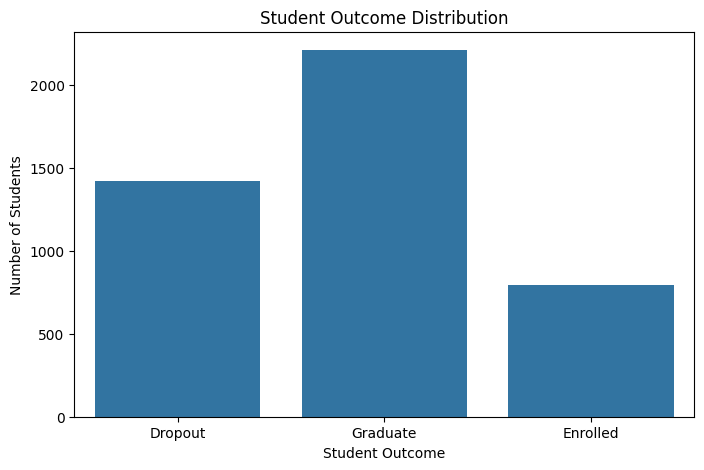

In [142]:
plt.figure(figsize=(8, 5))

sns.countplot(data=df, x="Target")

plt.title("Student Outcome Distribution")
plt.xlabel("Student Outcome")
plt.ylabel("Number of Students")

plt.show()

In [143]:
df["Age at enrollment"].describe()

count    4424.000000
mean       23.265145
std         7.587816
min        17.000000
25%        19.000000
50%        20.000000
75%        25.000000
max        70.000000
Name: Age at enrollment, dtype: float64

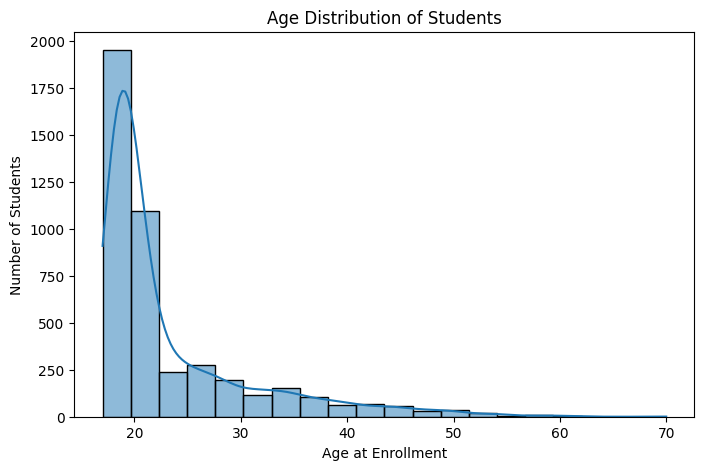

In [144]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="Age at enrollment",
    bins=20,
    kde=True
)

plt.title("Age Distribution of Students")
plt.xlabel("Age at Enrollment")
plt.ylabel("Number of Students")

plt.show()

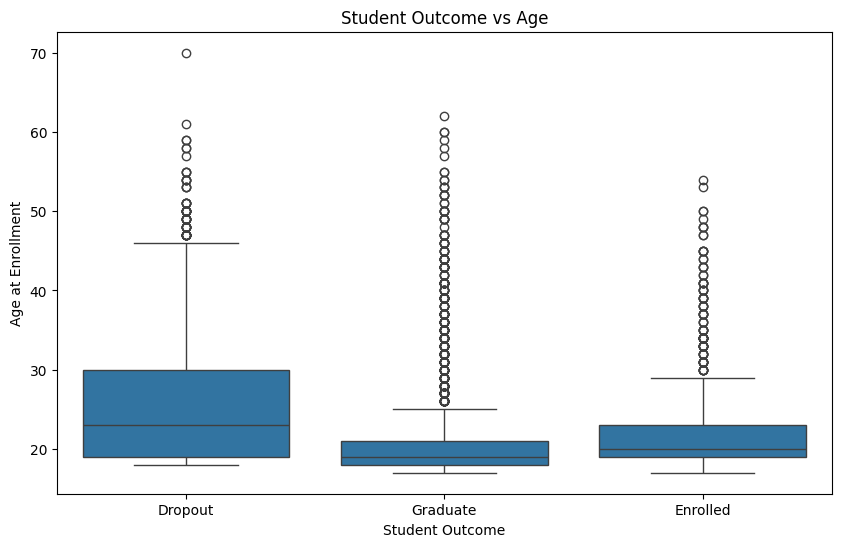

In [145]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="Target",
    y="Age at enrollment"
)

plt.title("Student Outcome vs Age")
plt.xlabel("Student Outcome")
plt.ylabel("Age at Enrollment")

plt.show()

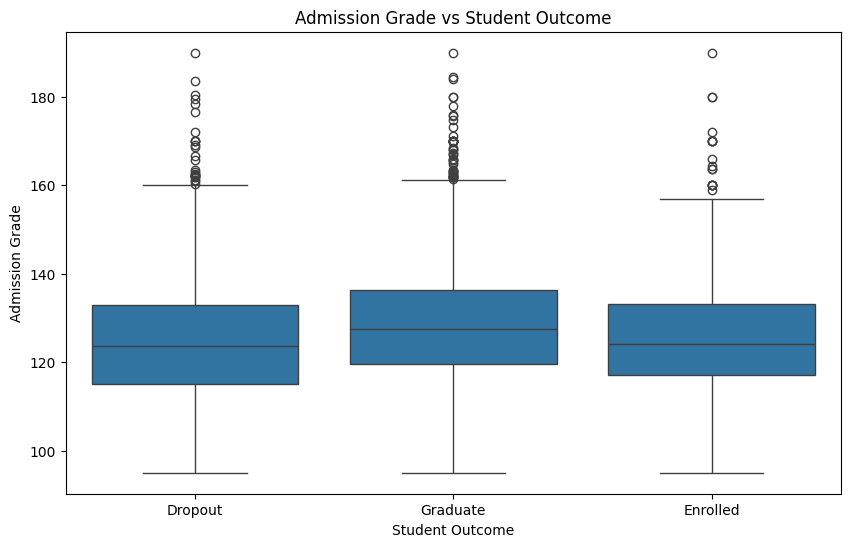

In [146]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="Target",
    y="Admission grade"
)

plt.title("Admission Grade vs Student Outcome")
plt.xlabel("Student Outcome")
plt.ylabel("Admission Grade")

plt.show()

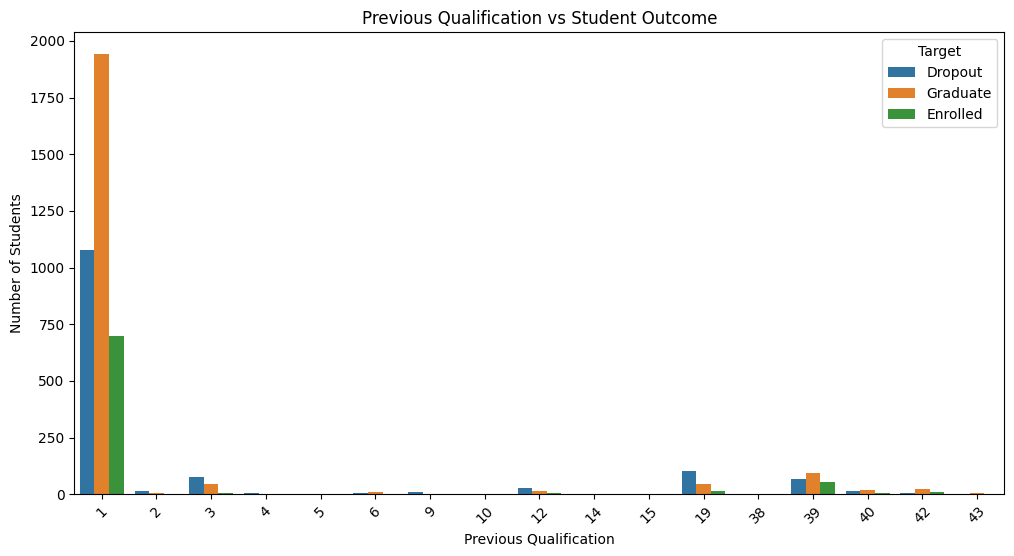

In [147]:
plt.figure(figsize=(12, 6))

sns.countplot(
    data=df,
    x="Previous qualification",
    hue="Target"
)

plt.title("Previous Qualification vs Student Outcome")
plt.xlabel("Previous Qualification")
plt.ylabel("Number of Students")

plt.xticks(rotation=45)

plt.show()

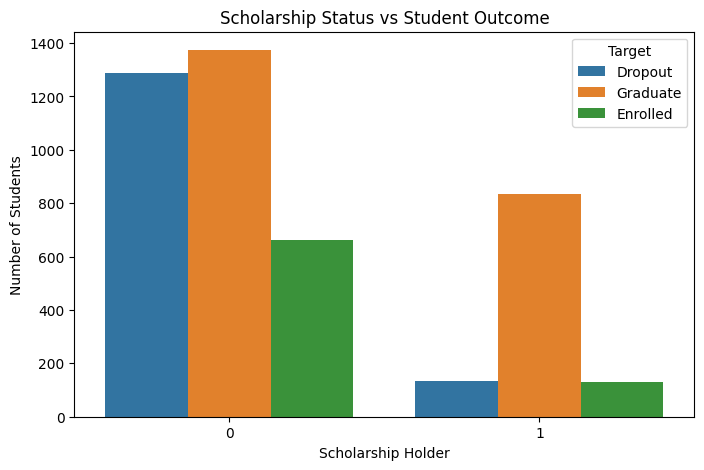

In [148]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="Scholarship holder",
    hue="Target"
)

plt.title("Scholarship Status vs Student Outcome")
plt.xlabel("Scholarship Holder")
plt.ylabel("Number of Students")

plt.show()

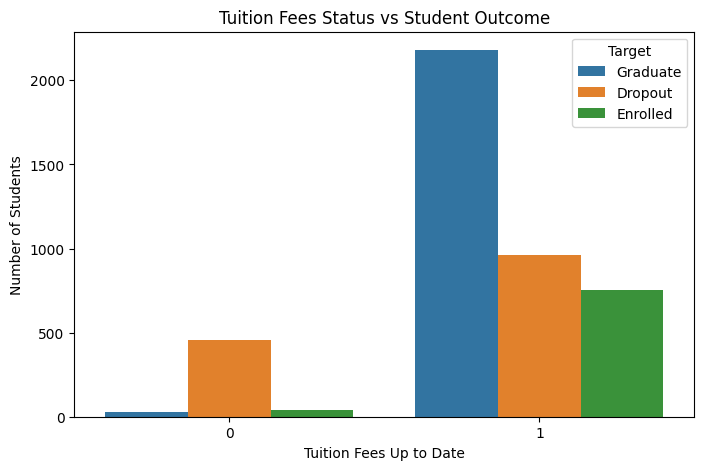

In [149]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="Tuition fees up to date",
    hue="Target"
)

plt.title("Tuition Fees Status vs Student Outcome")
plt.xlabel("Tuition Fees Up to Date")
plt.ylabel("Number of Students")

plt.show()

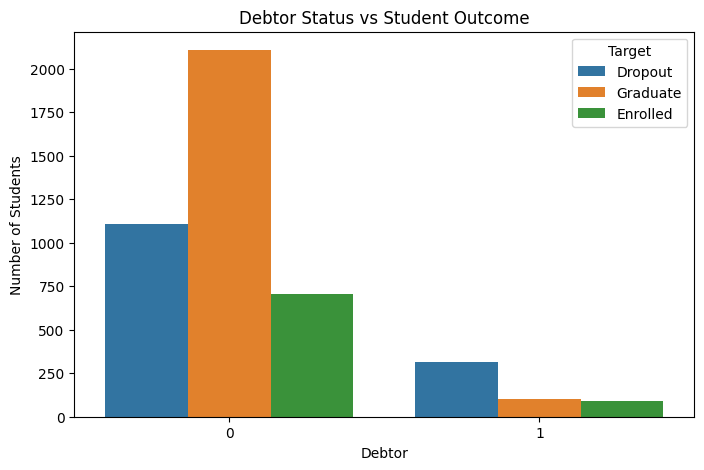

In [150]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="Debtor",
    hue="Target"
)

plt.title("Debtor Status vs Student Outcome")
plt.xlabel("Debtor")
plt.ylabel("Number of Students")

plt.show()

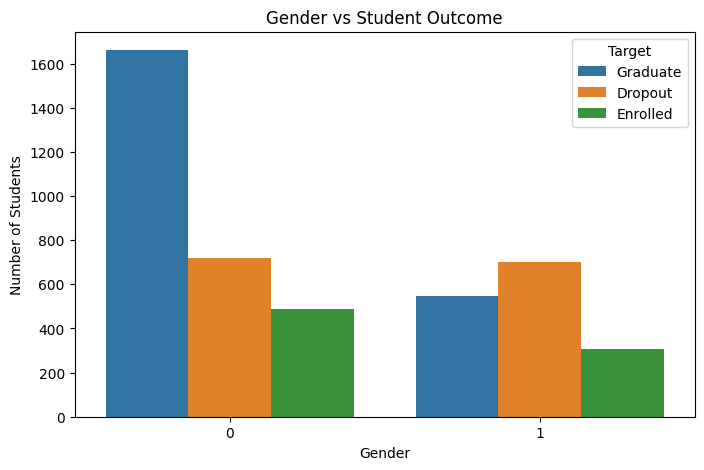

In [151]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="Gender",
    hue="Target"
)

plt.title("Gender vs Student Outcome")
plt.xlabel("Gender")
plt.ylabel("Number of Students")

plt.show()

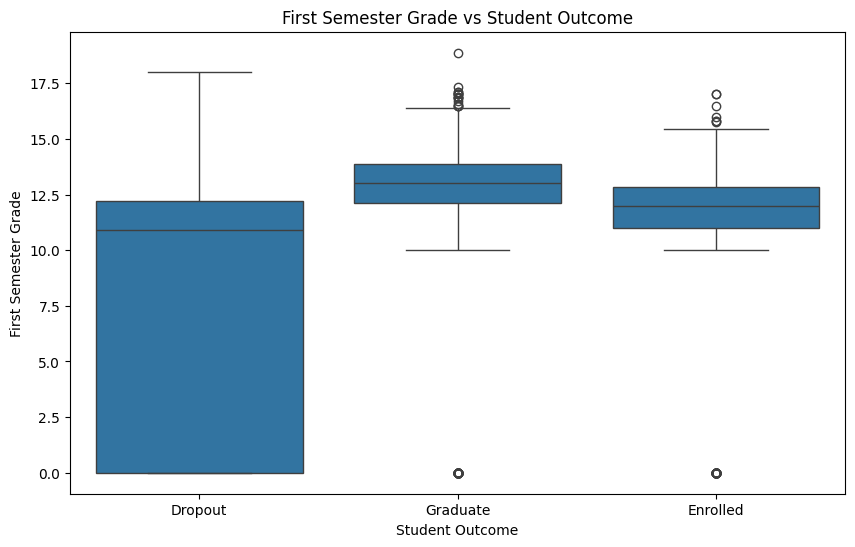

In [152]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="Target",
    y="Curricular units 1st sem (grade)"
)

plt.title("First Semester Grade vs Student Outcome")
plt.xlabel("Student Outcome")
plt.ylabel("First Semester Grade")

plt.show()

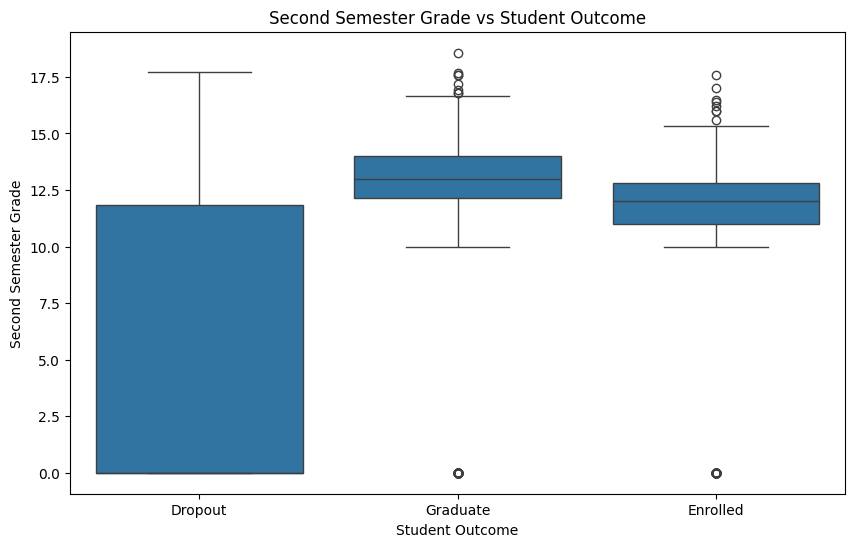

In [153]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="Target",
    y="Curricular units 2nd sem (grade)"
)

plt.title("Second Semester Grade vs Student Outcome")
plt.xlabel("Student Outcome")
plt.ylabel("Second Semester Grade")

plt.show()

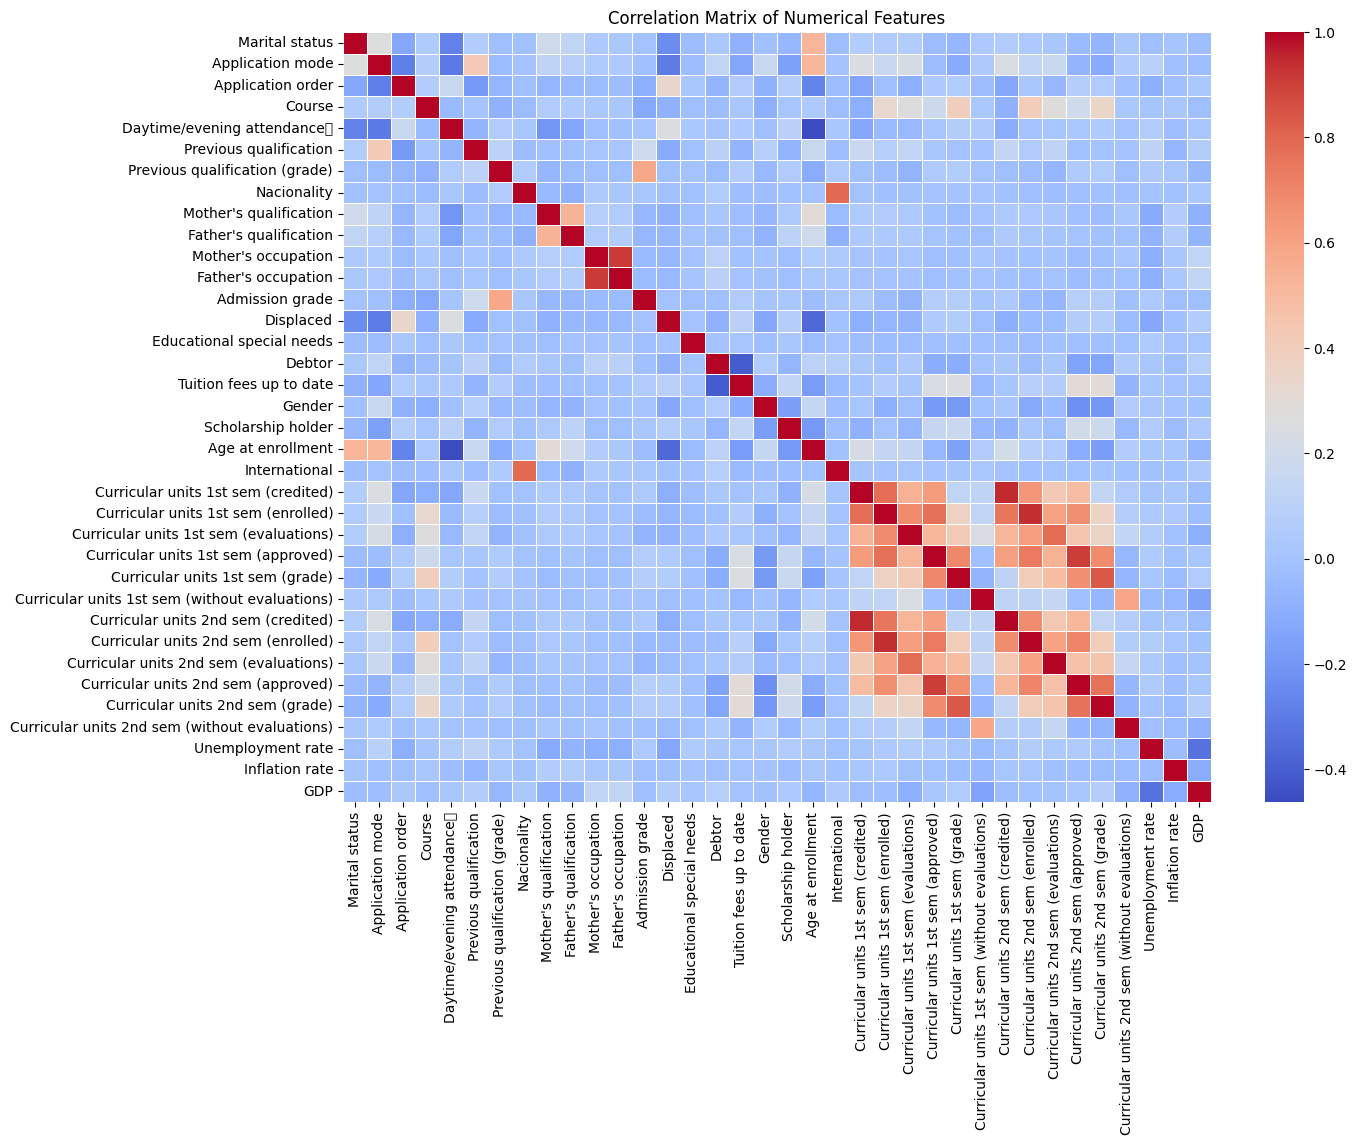

In [154]:
plt.figure(figsize=(14, 10))

correlation_matrix = df[numerical_columns].corr()

sns.heatmap(
    correlation_matrix,
    annot=False,
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Matrix of Numerical Features")

plt.show()

In [155]:
target_mapping = {
    "Dropout": 0,
    "Enrolled": 1,
    "Graduate": 2
}

df_corr = df.copy()

df_corr["Target_encoded"] = df_corr["Target"].map(target_mapping)

target_correlations = (
    df_corr.corr(numeric_only=True)["Target_encoded"]
    .sort_values(ascending=False)
)

target_correlations

Target_encoded                                    1.000000
Curricular units 2nd sem (approved)               0.624157
Curricular units 2nd sem (grade)                  0.566827
Curricular units 1st sem (approved)               0.529123
Curricular units 1st sem (grade)                  0.485207
Tuition fees up to date                           0.409827
Scholarship holder                                0.297595
Curricular units 2nd sem (enrolled)               0.175847
Curricular units 1st sem (enrolled)               0.155974
Admission grade                                   0.120889
Displaced                                         0.113986
Previous qualification (grade)                    0.103764
Curricular units 2nd sem (evaluations)            0.092721
Application order                                 0.089791
Daytime/evening attendance\t                      0.075107
Curricular units 2nd sem (credited)               0.054004
Curricular units 1st sem (credited)               0.0481

In [156]:
top_correlations = (
    target_correlations
    .drop("Target_encoded")
    .abs()
    .sort_values(ascending=False)
    .head(10)
)

print("Top 10 features correlated with the target:")
print(top_correlations)

Top 10 features correlated with the target:
Curricular units 2nd sem (approved)    0.624157
Curricular units 2nd sem (grade)       0.566827
Curricular units 1st sem (approved)    0.529123
Curricular units 1st sem (grade)       0.485207
Tuition fees up to date                0.409827
Scholarship holder                     0.297595
Age at enrollment                      0.243438
Debtor                                 0.240999
Gender                                 0.229270
Application mode                       0.221747
Name: Target_encoded, dtype: float64


## 4. Final EDA Summary
## EDA Summary

The exploratory analysis revealed several important patterns in the student dataset:

- The target variable contains three outcomes: Dropout, Enrolled, and Graduate.
- The classes are imbalanced, with Graduate representing the largest group.
- Student age shows differences across outcome categories.
- Admission grade appears to be associated with student outcomes.
- Financial indicators such as tuition-fee status and debtor status show differences across outcome groups.
- Scholarship status also shows variation across student outcomes.
- First- and second-semester academic performance appear to be important predictors of student success.
- Correlation analysis was used to identify potentially informative numerical features.
- Missing values and duplicate records were checked before proceeding to preprocessing.

These findings will guide the feature engineering and machine learning stages of the project.

## Part 4 — Separate Features and Target

In [157]:
# Clean column names
df.columns = df.columns.str.strip()

# Check
print(df.columns.tolist())

['Marital status', 'Application mode', 'Application order', 'Course', 'Daytime/evening attendance', 'Previous qualification', 'Previous qualification (grade)', 'Nacionality', "Mother's qualification", "Father's qualification", "Mother's occupation", "Father's occupation", 'Admission grade', 'Displaced', 'Educational special needs', 'Debtor', 'Tuition fees up to date', 'Gender', 'Scholarship holder', 'Age at enrollment', 'International', 'Curricular units 1st sem (credited)', 'Curricular units 1st sem (enrolled)', 'Curricular units 1st sem (evaluations)', 'Curricular units 1st sem (approved)', 'Curricular units 1st sem (grade)', 'Curricular units 1st sem (without evaluations)', 'Curricular units 2nd sem (credited)', 'Curricular units 2nd sem (enrolled)', 'Curricular units 2nd sem (evaluations)', 'Curricular units 2nd sem (approved)', 'Curricular units 2nd sem (grade)', 'Curricular units 2nd sem (without evaluations)', 'Unemployment rate', 'Inflation rate', 'GDP', 'Target']


In [158]:
X = df.drop('Target', axis=1)
y = df['Target']

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (4424, 36)
y shape: (4424,)


## Part 5 — Identify Numerical and Categorical Features

In [159]:
categorical_features = [
    'Marital status',
    'Application mode',
    'Application order',
    'Course',
    'Daytime/evening attendance',
    'Previous qualification',
    'Nacionality',
    "Mother's qualification",
    "Father's qualification",
    "Mother's occupation",
    "Father's occupation",
    'Displaced',
    'Educational special needs',
    'Debtor',
    'Tuition fees up to date',
    'Gender',
    'Scholarship holder',
    'International'
]

numerical_features = [
    'Previous qualification (grade)',
    'Admission grade',
    'Age at enrollment',
    'Curricular units 1st sem (credited)',
    'Curricular units 1st sem (enrolled)',
    'Curricular units 1st sem (evaluations)',
    'Curricular units 1st sem (approved)',
    'Curricular units 1st sem (grade)',
    'Curricular units 1st sem (without evaluations)',
    'Curricular units 2nd sem (credited)',
    'Curricular units 2nd sem (enrolled)',
    'Curricular units 2nd sem (evaluations)',
    'Curricular units 2nd sem (approved)',
    'Curricular units 2nd sem (grade)',
    'Curricular units 2nd sem (without evaluations)',
    'Unemployment rate',
    'Inflation rate',
    'GDP'
]

print("Categorical features:", len(categorical_features))
print("Numerical features:", len(numerical_features))
print("Total features:", len(categorical_features) + len(numerical_features))

Categorical features: 18
Numerical features: 18
Total features: 36


## Part 5 — Verify All Columns Are Included

In [160]:
all_features = categorical_features + numerical_features

missing_from_lists = set(X.columns) - set(all_features)
extra_in_lists = set(all_features) - set(X.columns)

print("Features missing from our lists:", missing_from_lists)
print("Extra features in our lists:", extra_in_lists)

Features missing from our lists: set()
Extra features in our lists: set()


## Part 6 — Train/Test Split

In [161]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 3539
Testing samples: 885


In [162]:
print("Daytime column exists in X:", 
      'Daytime/evening attendance' in X.columns)

print("Daytime column exists in X_train:", 
      'Daytime/evening attendance' in X_train.columns)

Daytime column exists in X: True
Daytime column exists in X_train: True


## Part 7 — Build Preprocessing Pipeline

In [163]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(
    transformers=[
        (
            'num',
            StandardScaler(),
            numerical_features
        ),
        (
            'cat',
            OneHotEncoder(
                handle_unknown='ignore',
                sparse_output=False
            ),
            categorical_features
        )
    ]
)

print("Preprocessor created successfully.")

Preprocessor created successfully.


## Part 8 — Logistic Regression Pipeline

In [164]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

logistic_pipeline = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('classifier', LogisticRegression(
            max_iter=2000,
            class_weight='balanced',
            random_state=42
        ))
    ]
)

logistic_pipeline.fit(X_train, y_train)

print("Logistic Regression trained successfully!")

Logistic Regression trained successfully!


## Logistic Regression Evaluation

In [165]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

# Predictions
y_pred_lr = logistic_pipeline.predict(X_test)

# Metrics
accuracy_lr = accuracy_score(y_test, y_pred_lr)

precision_lr = precision_score(
    y_test,
    y_pred_lr,
    average='weighted'
)

recall_lr = recall_score(
    y_test,
    y_pred_lr,
    average='weighted'
)

f1_lr = f1_score(
    y_test,
    y_pred_lr,
    average='weighted'
)

print("===== Logistic Regression =====")
print("Accuracy :", round(accuracy_lr, 4))
print("Precision:", round(precision_lr, 4))
print("Recall   :", round(recall_lr, 4))
print("F1 Score :", round(f1_lr, 4))

===== Logistic Regression =====
Accuracy : 0.7254
Precision: 0.7678
Recall   : 0.7254
F1 Score : 0.7392


In [166]:
print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr))


Classification Report:
              precision    recall  f1-score   support

     Dropout       0.82      0.68      0.75       284
    Enrolled       0.41      0.64      0.50       159
    Graduate       0.86      0.78      0.82       442

    accuracy                           0.73       885
   macro avg       0.70      0.70      0.69       885
weighted avg       0.77      0.73      0.74       885



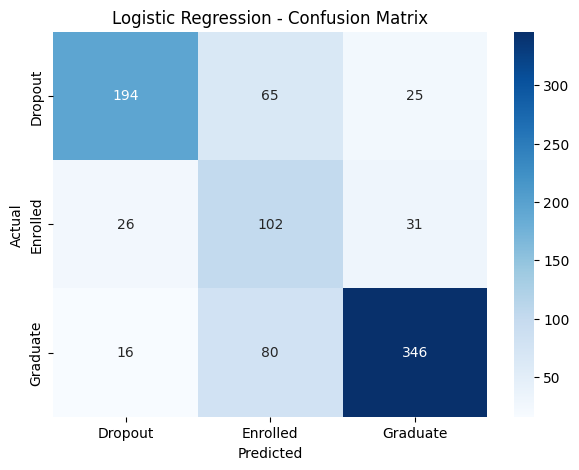

In [167]:
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=sorted(y.unique()),
    yticklabels=sorted(y.unique())
)

plt.title('Logistic Regression - Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

## Part 9 - Random Forest

In [168]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline

random_forest_pipeline = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('classifier', RandomForestClassifier(
            n_estimators=300,
            class_weight='balanced',
            random_state=42,
            n_jobs=-1
        ))
    ]
)

random_forest_pipeline.fit(X_train, y_train)

print("Random Forest trained successfully!")

Random Forest trained successfully!


In [169]:
y_pred_rf = random_forest_pipeline.predict(X_test)

accuracy_rf = accuracy_score(y_test, y_pred_rf)

precision_rf = precision_score(
    y_test,
    y_pred_rf,
    average='weighted'
)

recall_rf = recall_score(
    y_test,
    y_pred_rf,
    average='weighted'
)

f1_rf = f1_score(
    y_test,
    y_pred_rf,
    average='weighted'
)

print("===== Random Forest =====")
print("Accuracy :", round(accuracy_rf, 4))
print("Precision:", round(precision_rf, 4))
print("Recall   :", round(recall_rf, 4))
print("F1 Score :", round(f1_rf, 4))

===== Random Forest =====
Accuracy : 0.765
Precision: 0.7681
Recall   : 0.765
F1 Score : 0.7652


In [170]:
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))


Classification Report:
              precision    recall  f1-score   support

     Dropout       0.82      0.72      0.77       284
    Enrolled       0.50      0.53      0.51       159
    Graduate       0.83      0.88      0.86       442

    accuracy                           0.76       885
   macro avg       0.72      0.71      0.71       885
weighted avg       0.77      0.76      0.77       885



## Part 10 - XGBoost

In [171]:
# preprocess the data
from sklearn.preprocessing import LabelEncoder

# Fit preprocessing only on training data
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Processed training shape:", X_train_processed.shape)
print("Processed testing shape:", X_test_processed.shape)

Processed training shape: (3539, 251)
Processed testing shape: (885, 251)


In [172]:
label_encoder = LabelEncoder()

y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

print("Target classes:")
print(label_encoder.classes_)

Target classes:
['Dropout' 'Enrolled' 'Graduate']


In [173]:
# Train the XGBoost model
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='multi:softmax',
    num_class=3,
    eval_metric='mlogloss',
    random_state=42
)

xgb_model.fit(
    X_train_processed,
    y_train_encoded
)

print("XGBoost trained successfully!")

XGBoost trained successfully!


In [174]:
# Evaluate the XGBoost model
y_pred_xgb_encoded = xgb_model.predict(X_test_processed)

y_pred_xgb = label_encoder.inverse_transform(
    y_pred_xgb_encoded.astype(int)
)

accuracy_xgb = accuracy_score(y_test, y_pred_xgb)

precision_xgb = precision_score(
    y_test,
    y_pred_xgb,
    average='weighted'
)

recall_xgb = recall_score(
    y_test,
    y_pred_xgb,
    average='weighted'
)

f1_xgb = f1_score(
    y_test,
    y_pred_xgb,
    average='weighted'
)

print("===== XGBoost =====")
print("Accuracy :", round(accuracy_xgb, 4))
print("Precision:", round(precision_xgb, 4))
print("Recall   :", round(recall_xgb, 4))
print("F1 Score :", round(f1_xgb, 4))

===== XGBoost =====
Accuracy : 0.7605
Precision: 0.7509
Recall   : 0.7605
F1 Score : 0.7533


In [175]:
print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb))


Classification Report:
              precision    recall  f1-score   support

     Dropout       0.79      0.72      0.75       284
    Enrolled       0.51      0.43      0.47       159
    Graduate       0.81      0.90      0.86       442

    accuracy                           0.76       885
   macro avg       0.70      0.68      0.69       885
weighted avg       0.75      0.76      0.75       885



## Part 11 - Tune Random Forest

In [176]:
# import GridSearchCV for hyperparameter tuning
from sklearn.model_selection import GridSearchCV

# Define the parameter grid for hyperparameter tuning
param_grid = {
    'classifier__n_estimators': [200, 300],
    'classifier__max_depth': [10, 20, None],
    'classifier__min_samples_split': [2, 5],
    'classifier__min_samples_leaf': [1, 2]
}

In [177]:
# Run GridSearchCV to find the best hyperparameters
grid_search = GridSearchCV(
    estimator=random_forest_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring='f1_weighted',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest Cross-Validation F1 Score:")
print(round(grid_search.best_score_, 4))

Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best Parameters:
{'classifier__max_depth': None, 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 300}

Best Cross-Validation F1 Score:
0.7777


In [178]:
best_rf_model = grid_search.best_estimator_

print("Best Random Forest model selected.")

Best Random Forest model selected.


In [179]:
# Evaluate the tuned Random Forest model
y_pred_tuned_rf = best_rf_model.predict(X_test)

accuracy_tuned_rf = accuracy_score(
    y_test,
    y_pred_tuned_rf
)

precision_tuned_rf = precision_score(
    y_test,
    y_pred_tuned_rf,
    average='weighted'
)

recall_tuned_rf = recall_score(
    y_test,
    y_pred_tuned_rf,
    average='weighted'
)

f1_tuned_rf = f1_score(
    y_test,
    y_pred_tuned_rf,
    average='weighted'
)

print("===== Tuned Random Forest =====")
print("Accuracy :", round(accuracy_tuned_rf, 4))
print("Precision:", round(precision_tuned_rf, 4))
print("Recall   :", round(recall_tuned_rf, 4))
print("F1 Score :", round(f1_tuned_rf, 4))

===== Tuned Random Forest =====
Accuracy : 0.765
Precision: 0.7681
Recall   : 0.765
F1 Score : 0.7652


In [180]:
print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred_tuned_rf
    )
)


Classification Report:
              precision    recall  f1-score   support

     Dropout       0.82      0.72      0.77       284
    Enrolled       0.50      0.53      0.51       159
    Graduate       0.83      0.88      0.86       442

    accuracy                           0.76       885
   macro avg       0.72      0.71      0.71       885
weighted avg       0.77      0.76      0.77       885



## Compare Models

In [182]:
import pandas as pd

model_comparison = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Random Forest',
        'XGBoost'
    ],
    'Accuracy': [
        0.7254,
        0.7650,
        0.7605
    ],
    'Precision': [
        0.7678,
        0.7681,
        0.7509
    ],
    'Recall': [
        0.7254,
        0.7650,
        0.7605
    ],
    'F1 Score': [
        0.7392,
        0.7652,
        0.7533
    ]
})

print("===== MODEL COMPARISON =====")
display(model_comparison)

===== MODEL COMPARISON =====


,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.7254,0.7678,0.7254,0.7392
1,Random Forest,0.7650,0.7681,0.7650,0.7652
2,XGBoost,0.7605,0.7509,0.7605,0.7533


In [183]:
best_model_name = model_comparison.loc[
    model_comparison['F1 Score'].idxmax(),
    'Model'
]

best_accuracy = model_comparison['Accuracy'].max()
best_f1 = model_comparison['F1 Score'].max()

print("Best Model:", best_model_name)
print("Best Accuracy:", best_accuracy)
print("Best F1 Score:", best_f1)

Best Model: Random Forest
Best Accuracy: 0.765
Best F1 Score: 0.7652


## Save the model

In [184]:
import joblib

model_path = "student_outcome_model.joblib"

joblib.dump(random_forest_pipeline, model_path)

print(f"Best model saved successfully: {model_path}")

Best model saved successfully: student_outcome_model.joblib


## Test the saved model

In [185]:
loaded_model = joblib.load("student_outcome_model.joblib")

test_prediction = loaded_model.predict(X_test)

print("Model loaded successfully!")
print("Test Accuracy:",
      round((test_prediction == y_test).mean(), 4))

Model loaded successfully!
Test Accuracy: 0.765


## Save the model comparison

In [186]:
model_comparison.to_csv(
    "model_comparison.csv",
    index=False
)

print("Model comparison saved successfully!")

Model comparison saved successfully!
